In [1]:
# ==========================================================
# Notebook 3
# Classical 3D Cell Detection Baseline
# ==========================================================

from pathlib import Path

import zarr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from scipy import ndimage

from skimage.filters import gaussian
from skimage.filters import difference_of_gaussians
from skimage.feature import blob_log
from skimage.feature import peak_local_max
from skimage import exposure

plt.style.use("ggplot")

In [2]:
DATASET = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")

TRAIN = DATASET / "train"

sample = sorted(TRAIN.glob("*.zarr"))[0]

volume = zarr.open(sample)["0"]

print(volume.shape)

(100, 64, 256, 256)


In [3]:
geff = zarr.open(sample.with_suffix(".geff"))

gt = pd.DataFrame({

    "node_id": np.array(geff["nodes"]["ids"]),

    "t": np.array(geff["nodes"]["props"]["t"]["values"]),

    "z": np.array(geff["nodes"]["props"]["z"]["values"]),

    "y": np.array(geff["nodes"]["props"]["y"]["values"]),

    "x": np.array(geff["nodes"]["props"]["x"]["values"])

})

In [4]:
t = 30

img = volume[t].astype(np.float32)

In [5]:
img -= img.min()
img /= img.max()

In [6]:
img = exposure.equalize_adapthist(img)

In [7]:
# ============================================================
# Gaussian Smoothing
# ============================================================

from skimage.filters import gaussian

smooth = gaussian(
    img,
    sigma=1,
    preserve_range=True
)

print(smooth.shape)

(64, 256, 256)


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

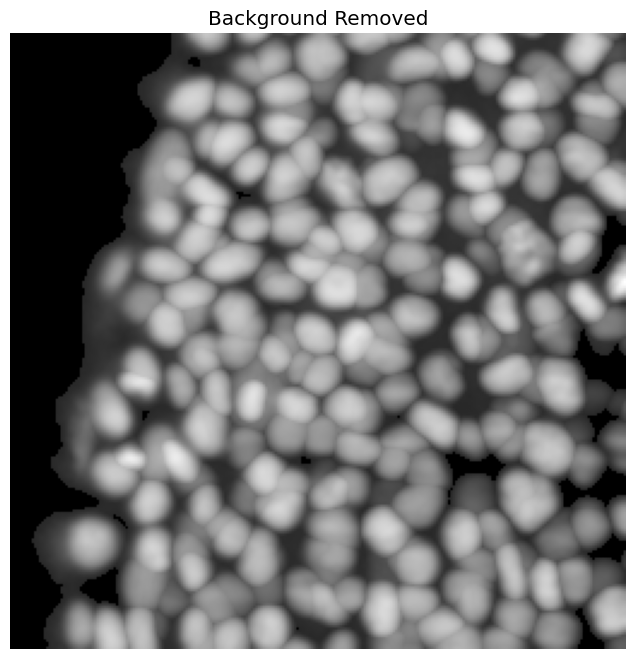

In [8]:
# ============================================================
# Background Mask
# ============================================================

mask = smooth > 0.15

smooth_masked = smooth.copy()
smooth_masked[~mask] = 0

plt.figure(figsize=(8,8))

plt.imshow(
    smooth_masked.max(axis=0),
    cmap="gray"
)

plt.title("Background Removed")

plt.axis("off")

In [9]:
# ============================================================
# Laplacian of Gaussian Blob Detection
# ============================================================

from skimage.feature import blob_log

blobs = blob_log(

    smooth_masked,

    min_sigma=3,

    max_sigma=6,

    num_sigma=5,

    threshold=0.08,

    overlap=0.4

)

print(f"Detected blobs : {len(blobs)}")

Detected blobs : 258


In [10]:
# ============================================================
# Convert to DataFrame
# ============================================================

pred = pd.DataFrame(

    blobs,

    columns=["z","y","x","radius"]

)

pred.head()

,z,y,x,radius
0,63.0,102.0,255.0,4.50
1,63.0,111.0,239.0,4.50
2,0.0,211.0,34.0,5.25
3,0.0,26.0,75.0,5.25
4,48.0,101.0,186.0,3.75


In [11]:
# ============================================================
# Non Maximum Suppression
# ============================================================

from scipy.spatial import KDTree

coords = pred[["z","y","x"]].values

tree = KDTree(coords)

keep = np.ones(len(pred), dtype=bool)

radius = 5

for i in range(len(coords)):

    if not keep[i]:
        continue

    neighbors = tree.query_ball_point(
        coords[i],
        r=radius
    )

    for j in neighbors:

        if j > i:

            keep[j] = False

pred = pred[keep].reset_index(drop=True)

print("Remaining detections:", len(pred))

Remaining detections: 258


In [12]:
# ============================================================
# Remove Small Blobs
# ============================================================

pred = pred[
    pred.radius > 2.5
].reset_index(drop=True)

print("Final detections:", len(pred))

Final detections: 258


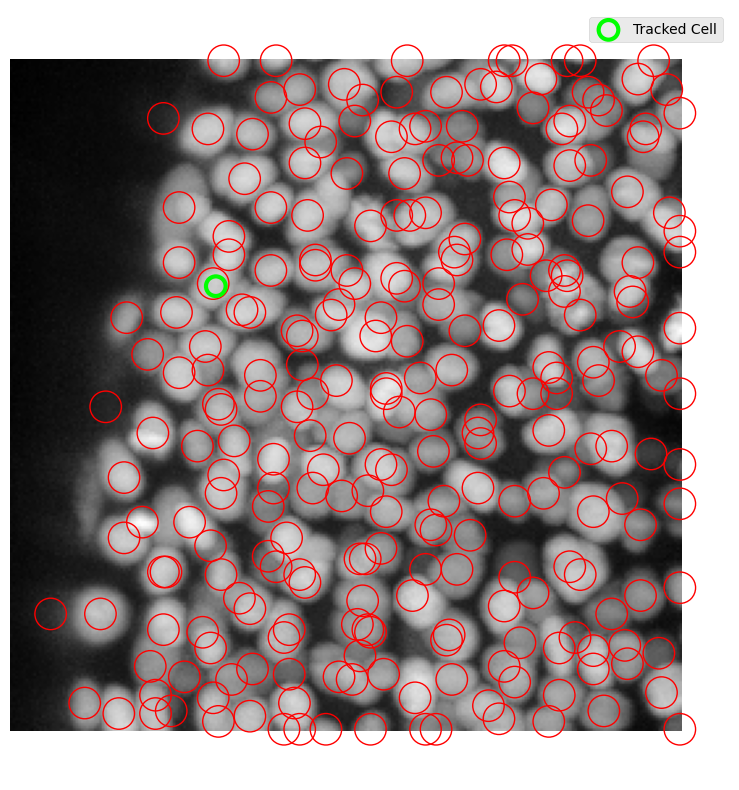

In [13]:
# ============================================================
# Overlay Detection
# ============================================================

from matplotlib.patches import Circle

truth = gt[gt.t == t]

mip = img.max(axis=0)

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(
    mip,
    cmap="gray"
)

for _, row in pred.iterrows():

    circle = Circle(

        (row.x,row.y),

        radius=6,

        edgecolor="red",

        facecolor="none",

        linewidth=1

    )

    ax.add_patch(circle)

ax.scatter(

    truth.x,

    truth.y,

    s=200,

    edgecolor="lime",

    facecolor="none",

    linewidth=3,

    label="Tracked Cell"

)

ax.legend()

ax.axis("off")

plt.show()

In [14]:
pred["intensity"] = [

    img[int(z), int(y), int(x)]

    for z, y, x in pred[["z","y","x"]].values

]

pred.head()

,z,y,x,radius,intensity
0,63.0,102.0,255.0,4.50,0.959774
1,63.0,111.0,239.0,4.50,0.680650
2,0.0,211.0,34.0,5.25,0.651003
3,0.0,26.0,75.0,5.25,0.728503
4,48.0,101.0,186.0,3.75,0.853795


Text(0.5, 1.0, 'Detection Intensities')

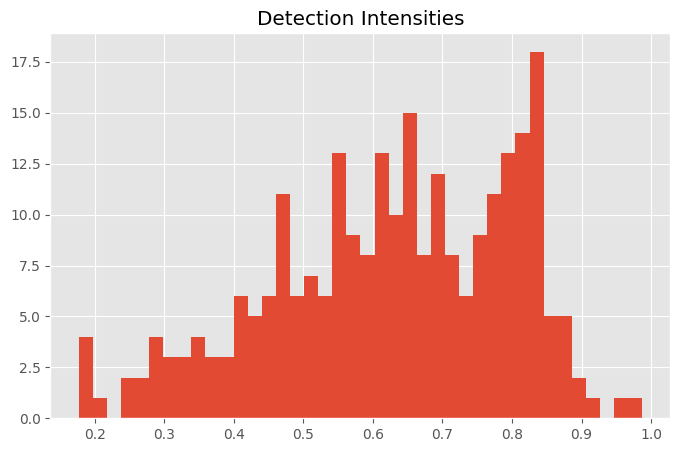

In [15]:
plt.figure(figsize=(8,5))

plt.hist(pred.intensity, bins=40)

plt.title("Detection Intensities")

In [16]:
# ============================================================
# Interactive 3D Detection
# ============================================================

import plotly.express as px

fig = px.scatter_3d(

    pred,

    x="x",

    y="y",

    z="z",

    color="radius",

    size="radius",

    opacity=0.75,

    color_continuous_scale="Turbo"

)

fig.update_layout(

    title="Detected Cell Candidates"

)

fig.show()

In [17]:
# ============================================================
# Detection Statistics
# ============================================================

pred["intensity"] = [

    img[
        int(z),
        int(y),
        int(x)
    ]

    for z,y,x in pred[["z","y","x"]].values

]

display(pred.head())

print()

print(pred.describe())

,z,y,x,radius,intensity
0,63.0,102.0,255.0,4.50,0.959774
1,63.0,111.0,239.0,4.50,0.680650
2,0.0,211.0,34.0,5.25,0.651003
3,0.0,26.0,75.0,5.25,0.728503
4,48.0,101.0,186.0,3.75,0.853795



                z           y           x      radius   intensity
count  258.000000  258.000000  258.000000  258.000000  258.000000
mean    29.453489  131.604645  151.620148    3.514535    0.625620
std     18.850004   77.254318   60.479301    0.742034    0.174138
min      0.000000    0.000000   15.000000    3.000000    0.176836
25%     13.250000   69.000000  104.000000    3.000000    0.513824
50%     30.000000  129.500000  151.000000    3.000000    0.642853
75%     43.750000  198.500000  204.750000    3.750000    0.778432
max     63.000000  255.000000  255.000000    6.000000    0.987329


In [18]:
fig = px.imshow(
    np.max(img,axis=0),
    color_continuous_scale="gray"
)

fig.add_scatter(
    x=pred.x,
    y=pred.y,
    mode="markers",
    marker=dict(color="red",size=4),
    name="Detected"
)

fig.show()

In [19]:
FRAME_LIST = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

In [20]:
detections = []

for t in FRAME_LIST:

    img = volume[t].astype(np.float32)

    img -= img.min()
    img /= img.max()

    dog = difference_of_gaussians(
        img,
        low_sigma=1,
        high_sigma=3
    )

    blobs = blob_log(
        dog,
        min_sigma=1,
        max_sigma=5,
        threshold=0.03
    )

    for z, y, x, r in blobs:
        detections.append({
            "t": t,
            "z": z,
            "y": y,
            "x": x,
            "radius": r
        })

detections = pd.DataFrame(detections)

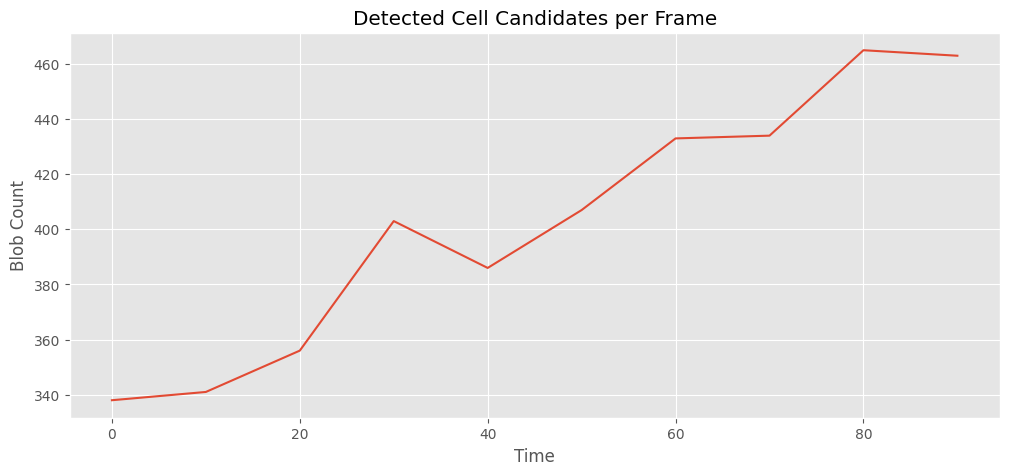

In [21]:
plt.figure(figsize=(12,5))

detections.groupby("t").size().plot()

plt.title("Detected Cell Candidates per Frame")

plt.ylabel("Blob Count")

plt.xlabel("Time")

plt.show()